In [1]:
import os, yaml, sys
from pathlib import Path
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import networkx as nx
from torchvision.datasets import ImageFolder
import random

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.yaml").exists())
NOTEBOOK_DIR = PROJECT_ROOT / "python_scripts" / "scripts"
os.chdir(NOTEBOOK_DIR)

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
for path_key in ["src_path", "useful_stuff_path"]:
    if path_key in paths and paths[path_key] not in sys.path:
        sys.path.append(paths[path_key])

from project_specific_utils.dataloader import load_img_natraster, map_image_order_from_ann_to_monkey
from II_analyses.static_dynII import init_static_dynII
from useful_stuff.general_utils.utils import print_wise, TimeSeries
from useful_stuff.image_processing.computational_models import get_relevant_output_layers

In [2]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'three0'
    date: str = '250313' # '250313' #  #  # # "230204"#'240816to26'
    brain_area: str = 'AIT'
    k=20
    new_fs: int = 100 # Hz
    model_name: str = 'vit_l_16'
    layer_name: str = 'blocks.16.mlp.fc2'
    signal_RDM_metric = "cosine_cnt"
    model_RDM_metric = "cosine_cnt"
    img_size: int = 384
    pooling: str = 'mean'
    pkg: str = 'timm'
    folder_name = 'talia_20each_tizi'
    subsamples_size = 200
    n_iterations = 20

cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
brain_areas = ['V1', 'V2', 'V3', 'PIT', 'CIT', 'AIT']

In [3]:
task_list = get_relevant_output_layers(cfg.model_name, cfg.pkg)
area_rasters = load_img_natraster(paths, cfg.monkey_name, cfg.date, new_fs=cfg.new_fs, brain_area=cfg.brain_area)

dataset = ImageFolder(
    root=f"{paths['livingstone_lab']}/Stimuli/{cfg.folder_name}/",
    is_valid_file=lambda x: not x.endswith("Thumbs.db"), 
    allow_empty=True, 
)
idx_ord = map_image_order_from_ann_to_monkey(paths, cfg.monkey_name, cfg.date, dataset)


In [4]:
layers_dict = {}
for l in layers:
    print_wise(f"starting layer {l}")
    feats_filename = f"{paths['data_path']}/models/{cfg.folder_name}_{cfg.model_name}_{cfg.img_size}_{l}_features_{cfg.pooling}pool.npz"
    features = np.load(feats_filename)["arr_0"][:, idx_ord]
    A2B_tot = []
    B2A_tot = []
    for i in range(cfg.n_iterations):
        subset = random.sample(range(len(idx_ord)), cfg.subsamples_size)
        subset_rasters = TimeSeries(area_rasters.get_array()[:,:,subset], cfg.new_fs)
        subset_features = features[:,subset]
        dyn_ii_obj = init_static_dynII(subset_rasters, cfg.signal_RDM_metric, cfg.model_RDM_metric, cfg.k)
        dyn_ii_obj.compute_RDM(subset_features, "model")
        dyn_ii_obj.compute_distance_ranks("model")
        dyn_ii = dyn_ii_obj.compute_both_static_dynII()
        A2B_tot.append(dyn_ii[0])
        B2A_tot.append(dyn_ii[1])

    A2B_tot = np.mean(A2B_tot, axis=0)
    B2A_tot = np.mean(B2A_tot, axis=0)
    layers_dict[f"{l}_A2B"] = A2B_tot
    layers_dict[f"{l}_B2A"] = B2A_tot




16:09:29 - starting layer blocks.0.mlp.fc2
16:09:31 - starting layer blocks.1.mlp.fc2
16:09:32 - starting layer blocks.2.mlp.fc2
16:09:34 - starting layer blocks.3.mlp.fc2
16:09:35 - starting layer blocks.4.mlp.fc2
16:09:36 - starting layer blocks.5.mlp.fc2
16:09:37 - starting layer blocks.6.mlp.fc2
16:09:38 - starting layer blocks.7.mlp.fc2
16:09:39 - starting layer blocks.8.mlp.fc2
16:09:40 - starting layer blocks.9.mlp.fc2
16:09:42 - starting layer blocks.10.mlp.fc2
16:09:43 - starting layer blocks.11.mlp.fc2
16:09:44 - starting layer blocks.12.mlp.fc2
16:09:45 - starting layer blocks.13.mlp.fc2
16:09:46 - starting layer blocks.14.mlp.fc2
16:09:47 - starting layer blocks.15.mlp.fc2
16:09:49 - starting layer blocks.16.mlp.fc2
16:09:50 - starting layer blocks.17.mlp.fc2
16:09:51 - starting layer blocks.18.mlp.fc2
16:09:52 - starting layer blocks.19.mlp.fc2
16:09:53 - starting layer blocks.20.mlp.fc2
16:09:54 - starting layer blocks.21.mlp.fc2
16:09:55 - starting layer blocks.22.mlp.fc

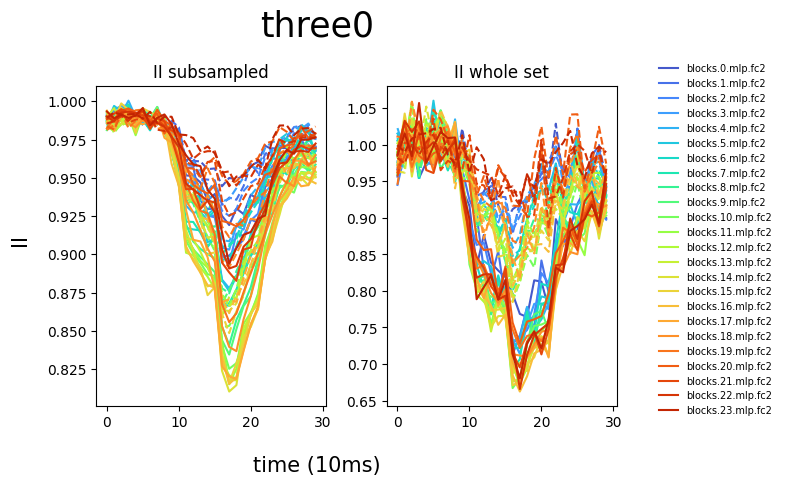

In [5]:
from useful_stuff.general_utils.plots import truncate_colormap
base_cmap = plt.cm.turbo
cmap = truncate_colormap(base_cmap, 0.10, 0.90)
fig, ax = plt.subplots(1, 2)
for i_col, l in enumerate(layers):
    color = cmap(i_col / (len(layers) - 1))
    ax[0].plot(layers_dict[f"{l}_A2B"], color=color, linestyle="--")
    ax[0].plot(layers_dict[f"{l}_B2A"], color=color, label=l)

for i_col, l in enumerate(layers):
    color = cmap(i_col / (len(layers) - 1))
    save_name_A2B = f"{paths['data_path']}/results/dynII_A2B_k{1}_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
    save_name_B2A = f"{paths['data_path']}/results/dynII_B2A_k{1}_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
    A2B = np.load(save_name_A2B)["arr_0"]
    B2A = np.load(save_name_B2A)["arr_0"]
    ax[1].plot(A2B, color=color, linestyle="--")
    ax[1].plot(B2A, color=color)

fig.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False, 
    fontsize=7
);

ax[0].set_title("II subsampled")
ax[1].set_title("II whole set")
fig.supylabel("II", fontsize=15)
fig.supxlabel("time (10ms)", fontsize=15)
fig.suptitle(f"{cfg.monkey_name}", fontsize=25)
plt.tight_layout()

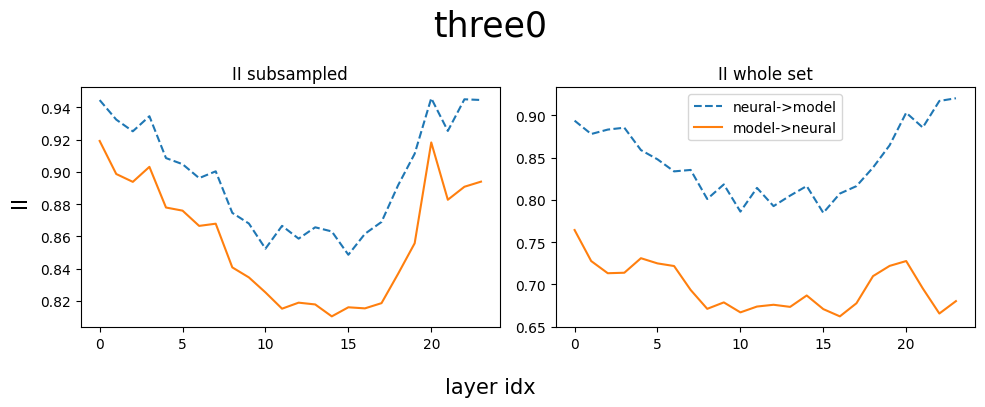

In [6]:
A2B_layers=[]
B2A_layers=[]
A2B_layers_gt=[]
B2A_layers_gt=[]
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for i_col, l in enumerate(layers):
    A2B_layers.append(np.min(layers_dict[f"{l}_A2B"]))
    B2A_layers.append(np.min(layers_dict[f"{l}_B2A"]))
for i_col, l in enumerate(layers):
    save_name_A2B = f"{paths['data_path']}/results/dynII_A2B_k{1}_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
    save_name_B2A = f"{paths['data_path']}/results/dynII_B2A_k{1}_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
    A2B = np.load(save_name_A2B)["arr_0"]
    B2A = np.load(save_name_B2A)["arr_0"]
    A2B_layers_gt.append(np.min(A2B))
    B2A_layers_gt.append(np.min(B2A))
ax[0].plot(A2B_layers, linestyle="--", label="neural->model") 
ax[0].plot(B2A_layers, label="model->neural") 
ax[1].plot(A2B_layers_gt, linestyle="--", label="neural->model") 
ax[1].plot(B2A_layers_gt, label="model->neural") 
ax[0].set_title("II subsampled")
ax[1].set_title("II whole set")
fig.supylabel("II", fontsize=15)
fig.supxlabel("layer idx", fontsize=15)
fig.suptitle(f"{cfg.monkey_name}", fontsize=25)
plt.legend()
plt.tight_layout()

Text(0.5, 0, 'layer idx')

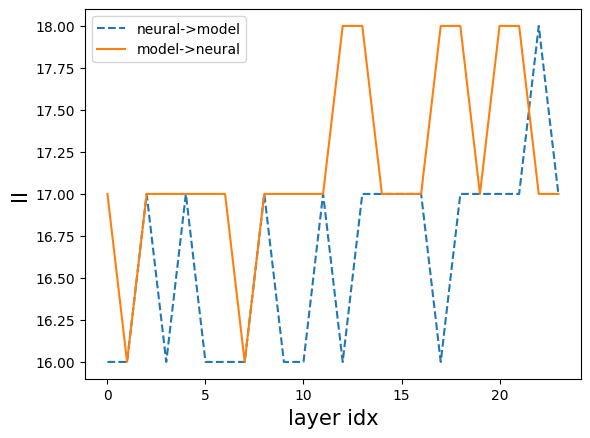

In [7]:
A2B_layers=[]
B2A_layers=[]
for i_col, l in enumerate(layers):
    A2B_layers.append(np.argmin(layers_dict[f"{l}_A2B"]))
    B2A_layers.append(np.argmin(layers_dict[f"{l}_B2A"]))
plt.plot(A2B_layers, linestyle="--", label="neural->model") 
plt.plot(B2A_layers, label="model->neural") 
plt.legend()
plt.ylabel("II", fontsize=15)
plt.xlabel("layer idx", fontsize=15)